In [2]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import ast

# Paths del proyecto
PROJECT_DIR = Path.cwd().parent
SCRIPTS_DIR = PROJECT_DIR / "scripts"
DATA_PROCESSED_DIR = PROJECT_DIR / "data_processed"
OUTPUT_DIR = PROJECT_DIR / "outputs"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

from sentiment_vad import (
    load_nrc_vad_lexicon,
    adapt_vad_lexicon_for_lol,
    apply_vad_to_dataframe,
)

In [3]:
df = pd.read_csv(DATA_PROCESSED_DIR / "reddit_clean.csv")
print(df.head())


for col in ["tokens", "tokens_no_stop"]:
    if col in df.columns:
        df[col] = df[col].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        )

print(type(df["tokens_no_stop"].iloc[0]), df["tokens_no_stop"].iloc[0][:10])

                                                body          created_utc  \
0  Done - your wish is our command.  Graves shall...  2017-04-01 16:01:43   
1  I don't play league but goddam it if I'm not g...  2017-04-01 03:56:12   
2         http://imgur.com/a/8F7c6 WE DID IT REDDIT!  2017-04-01 04:01:06   
3                                        Seems legit  2017-04-01 00:55:50   
4  Graves no cigar, graves in peril, not to worry...  2017-04-01 01:19:17   

   score           created_dt        date  year  month year_month  \
0   2022  2017-04-01 16:01:43  2017-04-01  2017      4    2017-04   
1   4183  2017-04-01 03:56:12  2017-04-01  2017      4    2017-04   
2    267  2017-04-01 04:01:06  2017-04-01  2017      4    2017-04   
3    978  2017-04-01 00:55:50  2017-04-01  2017      4    2017-04   
4    670  2017-04-01 01:19:17  2017-04-01  2017      4    2017-04   

                                          text_clean  \
0  done your wish is our command graves shall onc...   
1  i don t

In [4]:
VAD_PATH = PROJECT_DIR / "data_raw" / "NRC-VAD-Lexicon-v2.1.txt"
GAMEWORDS_PATH = OUTPUT_DIR / "game_mechanics_words.json"

vad_lexicon = load_nrc_vad_lexicon(VAD_PATH)
vad_lexicon_lol = adapt_vad_lexicon_for_lol(vad_lexicon, GAMEWORDS_PATH)
# 
print("Tamaño léxico original:", len(vad_lexicon))
print("Tamaño léxico adaptado:", len(vad_lexicon_lol))


Tamaño léxico original: 54801
Tamaño léxico adaptado: 54801


In [5]:
df_vad = apply_vad_to_dataframe(
    df=df,
    tokens_col="tokens_no_stop",
    lexicon=vad_lexicon_lol,
)

df_vad.head()


,body,created_utc,score,created_dt,date,year,month,year_month,text_clean,tokens,tokens_no_stop,n_tokens,n_tokens_no_stop,n_chars,vad_valence_mean,vad_arousal_mean,vad_dominance_mean
0,Done - your wish is our command. Graves shall...,2017-04-01 16:01:43,2022,2017-04-01 16:01:43,2017-04-01,2017,4,2017-04,done your wish is our command graves shall onc...,"[done, your, wish, is, our, command, graves, s...","[wish, command, graves, shall, puffing, fat, s...",28,11,134,0.028800,0.109800,0.097600
1,I don't play league but goddam it if I'm not g...,2017-04-01 03:56:12,4183,2017-04-01 03:56:12,2017-04-01,2017,4,2017-04,i don t play league but goddam it if i m not g...,"[i, don, t, play, league, but, goddam, it, if,...","[play, league, goddam, gonna, upvote, dreams, ...",25,10,115,0.327889,0.068222,0.133444
2,http://imgur.com/a/8F7c6 WE DID IT REDDIT!,2017-04-01 04:01:06,267,2017-04-01 04:01:06,2017-04-01,2017,4,2017-04,http imgur com a 8f7c6 we did it reddit,"[http, imgur, com, a, 8f7c6, we, did, it, reddit]","[imgur, 8f7c6, did, reddit]",9,4,42,0.000000,0.667000,0.000000
3,Seems legit,2017-04-01 00:55:50,978,2017-04-01 00:55:50,2017-04-01,2017,4,2017-04,seems legit,"[seems, legit]",[legit],2,1,11,0.494000,-0.146000,0.698000
4,"Graves no cigar, graves in peril, not to worry...",2017-04-01 01:19:17,670,2017-04-01 01:19:17,2017-04-01,2017,4,2017-04,graves no cigar graves in peril not to worry w...,"[graves, no, cigar, graves, in, peril, not, to...","[graves, cigar, graves, peril, worry, marc, me...",13,7,69,-0.598000,0.432667,-0.246000


In [6]:
sent_by_year = (
    df_vad.groupby("year")[["vad_valence_mean", "vad_arousal_mean", "vad_dominance_mean"]]
           .mean()
           .reset_index()
           .sort_values("year")
)

sent_by_year


,year,vad_valence_mean,vad_arousal_mean,vad_dominance_mean
0,2015,0.159194,0.017050,0.063151
1,2016,0.130773,0.042561,0.051405
2,2017,0.112470,0.045354,0.052723
3,2018,0.131145,0.018157,0.050956
4,2019,0.164347,0.011304,0.053145
5,2020,0.154233,0.022064,0.059367
6,2021,0.160539,0.017087,0.059864
7,2022,0.162328,0.029003,0.071184
8,2024,0.099469,0.062948,0.106309
9,2025,0.157489,0.000308,0.071219


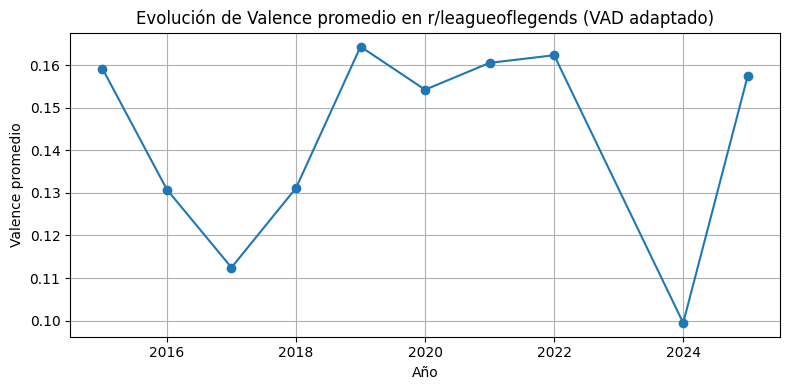

In [7]:
plt.figure(figsize=(8,4))
plt.plot(sent_by_year["year"], sent_by_year["vad_valence_mean"], marker="o")
plt.title("Evolución de Valence promedio en r/leagueoflegends (VAD adaptado)")
plt.xlabel("Año")
plt.ylabel("Valence promedio")
plt.grid(True)
plt.tight_layout()
plt.show()


In [8]:
def vad_coverage(df, lex):
    total = 0
    matched = 0
    for toks in df["tokens_no_stop"]:
        for t in toks:
            total += 1
            if t.lower() in lex:
                matched += 1
    return matched / total, matched, total

coverage, matched, total = vad_coverage(df_vad, vad_lexicon_lol)
coverage, matched, total


(0.670560231921594, 182269, 271816)

In [9]:
zero_mask = (df_vad["vad_valence_mean"] == 0.0)
zero_mask.mean()


np.float64(0.07136600784492936)

In [10]:
df_vad.to_csv(DATA_PROCESSED_DIR / "reddit_with_vad.csv", index=False)
sent_by_year.to_csv(DATA_PROCESSED_DIR / "sentiment_vad_by_year.csv", index=False)

print("Guardado reddit_with_vad.csv")
print("Guardado sentiment_vad_by_year.csv")


Guardado reddit_with_vad.csv
Guardado sentiment_vad_by_year.csv
